# Data Visualization and Statistical Analysis 

This notebook demonstrates key statistical analysis and visualization techniques using Python, `pandas`, `matplotlib`, and `seaborn`.

We analyze the Netflix movie database (`mymoviedb (1).csv`) and demonstrate:
1. **Central Tendency** 
2. **Outlier Identification** 
3. **Relationship between 2 Numeric Variables**
4. **Relationship between Numeric and Nominal Variables**
5. **Relationship between two Nominal Variables**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots to ensure premium and consistent design aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (10, 6)
})

# Load the data using the python engine to handle quotes in the Overview column
df = pd.read_csv("mymoviedb (1).csv", engine="python")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")

# Clean columns and extract Primary Genre
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Primary_Genre'] = df['Genre'].apply(
    lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'Unknown'
)
df = df.dropna(subset=['Vote_Average', 'Popularity', 'Vote_Count'])
print(f"Cleaned dataset: {df.shape[0]} rows.")


Loaded 9837 rows and 9 columns.
Cleaned dataset: 9826 rows.


## 1. Central Tendency of Data (Visual & Numeric)


Numeric Central Tendency for Vote_Average:
  Mean   : 6.439
  Median : 6.500
  Mode   : 6.400


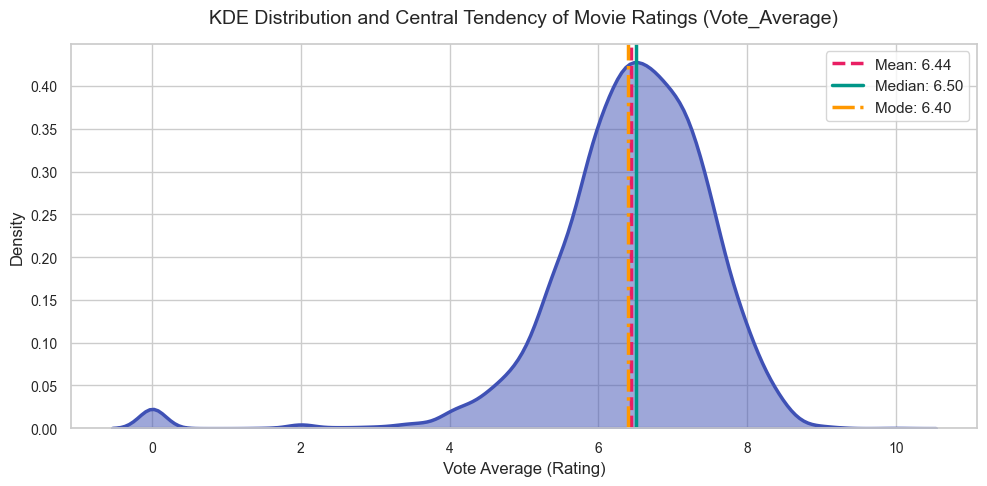

In [2]:
# Numeric Calculations
mean_val = df['Vote_Average'].mean()
median_val = df['Vote_Average'].median()
mode_val = df['Vote_Average'].mode()[0]

print(f"Numeric Central Tendency for Vote_Average:")
print(f"  Mean   : {mean_val:.3f}")
print(f"  Median : {median_val:.3f}")
print(f"  Mode   : {mode_val:.3f}")

# Visual Demonstration - Filled KDE (Kernel Density Estimate) Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(df['Vote_Average'], fill=True, color='#3f51b5', alpha=0.5, linewidth=2.5)

# Add vertical lines for central tendencies
plt.axvline(mean_val, color='#e91e63', linestyle='--', linewidth=2.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#009688', linestyle='-', linewidth=2.5, label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='#ff9800', linestyle='-.', linewidth=2.5, label=f'Mode: {mode_val:.2f}')

plt.title('KDE Distribution and Central Tendency of Movie Ratings (Vote_Average)', pad=15)
plt.xlabel('Vote Average (Rating)')
plt.ylabel('Density')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


## 2. Outlier Identification (Visual & Numeric)


Original Bounds: [4.10, 8.90]
Number of outliers in original data: 243 out of 9826
Modified Bounds (with synthetic outliers): [4.10, 8.90]
Number of outliers in modified data: 245


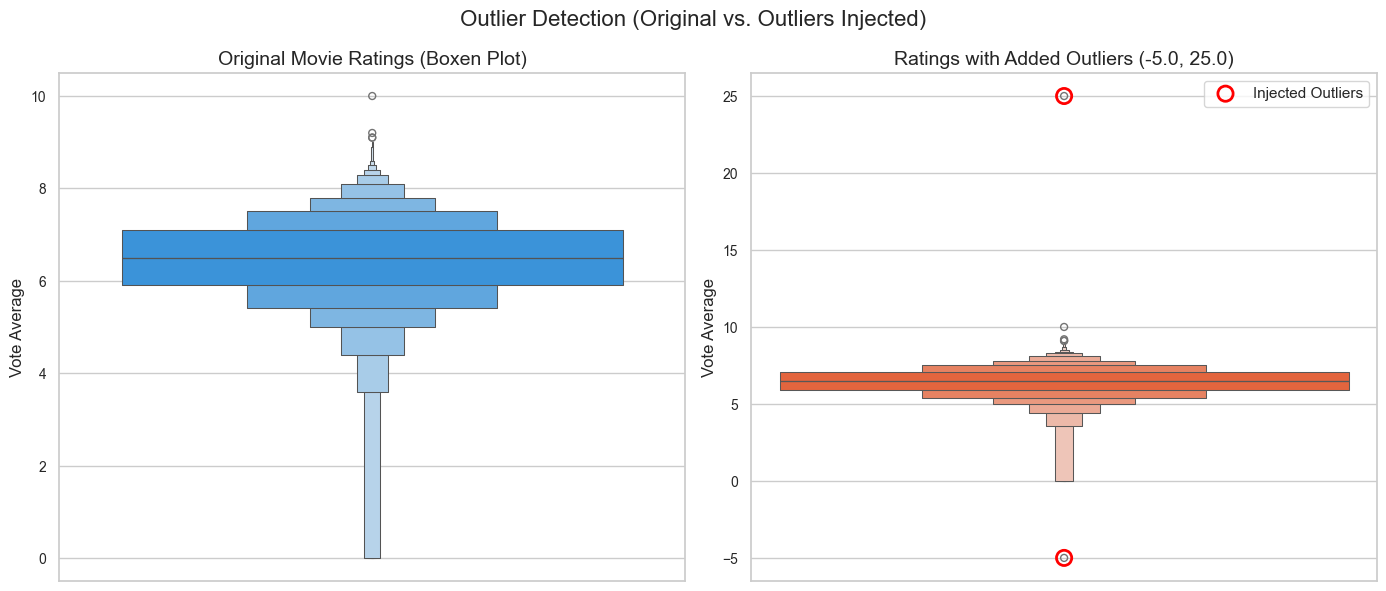

In [3]:
# Function to find outliers
def find_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

# 1. Original Data Outliers
orig_outliers, orig_lb, orig_ub = find_outliers_iqr(df['Vote_Average'])
print(f"Original Bounds: [{orig_lb:.2f}, {orig_ub:.2f}]")
print(f"Number of outliers in original data: {len(orig_outliers)} out of {len(df)}")

# 2. Add Synthetic Outliers
df_with_outliers = df.copy()
outlier_entries = pd.DataFrame([
    {'Release_Date': '2026-01-01', 'Title': 'Anomalous Flop', 'Popularity': 10.0, 'Vote_Count': 5, 'Vote_Average': -5.0, 'Original_Language': 'en', 'Primary_Genre': 'Action'},
    {'Release_Date': '2026-01-02', 'Title': 'Anomalous Masterpiece', 'Popularity': 100.0, 'Vote_Count': 10, 'Vote_Average': 25.0, 'Original_Language': 'en', 'Primary_Genre': 'Drama'}
])
df_with_outliers = pd.concat([df_with_outliers, outlier_entries], ignore_index=True)

# Re-calculate on modified data
mod_outliers, mod_lb, mod_ub = find_outliers_iqr(df_with_outliers['Vote_Average'])
print(f"Modified Bounds (with synthetic outliers): [{mod_lb:.2f}, {mod_ub:.2f}]")
print(f"Number of outliers in modified data: {len(mod_outliers)}")

# Visual Demonstration: Boxen Plots (Letter-Value Plots for large datasets)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxenplot(y=df['Vote_Average'], ax=axes[0], color='#2196f3')
axes[0].set_title('Original Movie Ratings (Boxen Plot)')
axes[0].set_ylabel('Vote Average')

sns.boxenplot(y=df_with_outliers['Vote_Average'], ax=axes[1], color='#ff5722')
axes[1].scatter([0, 0], [-5.0, 25.0], color='red', s=120, zorder=5, facecolors='none', edgecolors='red', linewidths=2, label='Injected Outliers')
axes[1].set_title('Ratings with Added Outliers (-5.0, 25.0)')
axes[1].set_ylabel('Vote Average')
axes[1].legend()

plt.suptitle('Outlier Detection (Original vs. Outliers Injected)', y=0.98)
plt.tight_layout()
plt.show()


## 3. Visualizing Relationship Between 2 Numeric Variables


Pearson Correlation Coefficient: 0.137


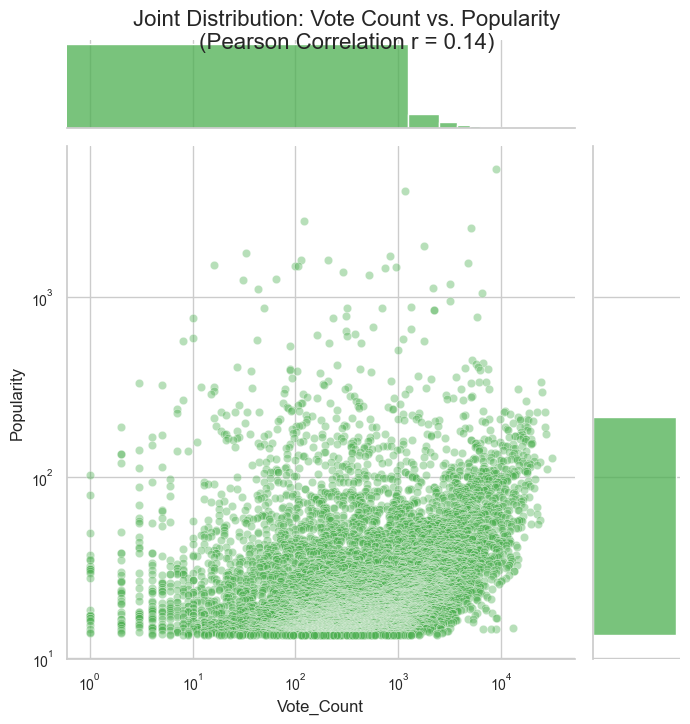

In [4]:
# Calculate Pearson correlation coefficient
correlation = df['Vote_Count'].corr(df['Popularity'])
print(f"Pearson Correlation Coefficient: {correlation:.3f}")

# Joint Plot
g = sns.jointplot(
    data=df, 
    x='Vote_Count', 
    y='Popularity', 
    kind='scatter',
    alpha=0.4,
    color='#4caf50',
    height=7,
    marginal_kws=dict(bins=25, fill=True)
)

# Apply log scales to both axes
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')

g.fig.suptitle(f'Joint Distribution: Vote Count vs. Popularity\n(Pearson Correlation r = {correlation:.2f})', y=1.02)
plt.show()


## 4. Visualizing Relationship Between Numeric and Nominal Variable


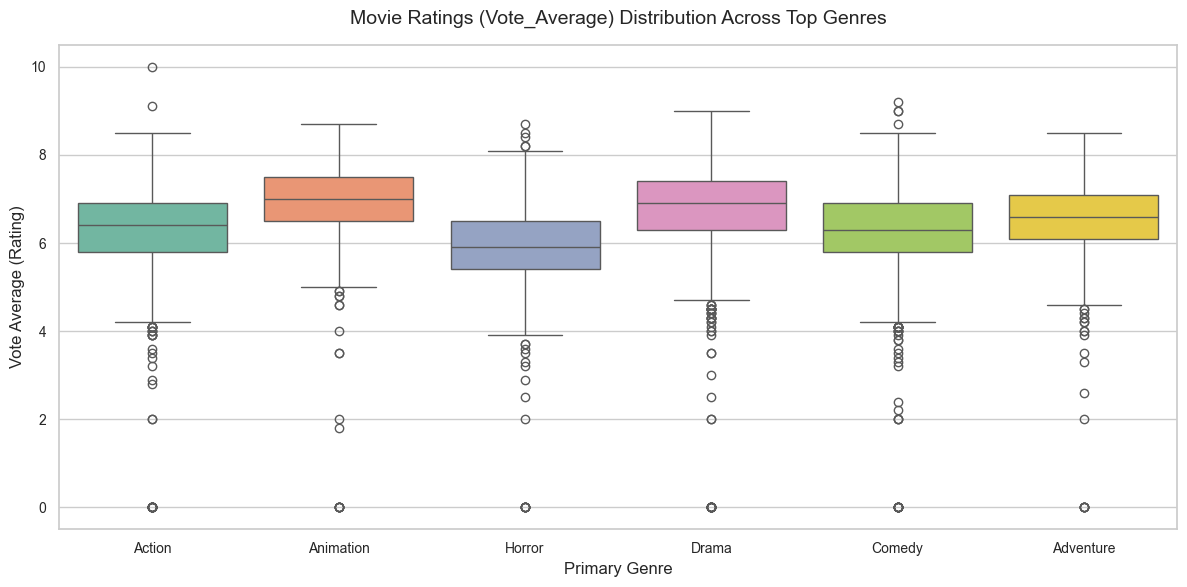

In [5]:
# Get top 6 genres
top_genres = df['Primary_Genre'].value_counts().nlargest(6).index
df_filtered_genres = df[df['Primary_Genre'].isin(top_genres)]

plt.figure(figsize=(12, 6))

# Box Plot
sns.boxplot(
    data=df_filtered_genres, 
    x='Primary_Genre', 
    y='Vote_Average',
    hue='Primary_Genre',
    legend=False,
    palette='Set2'
)

plt.title('Movie Ratings (Vote_Average) Distribution Across Top Genres', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Vote Average (Rating)')
plt.tight_layout()
plt.show()


## 5. Visualizing Relationship Between Two Nominal Variables


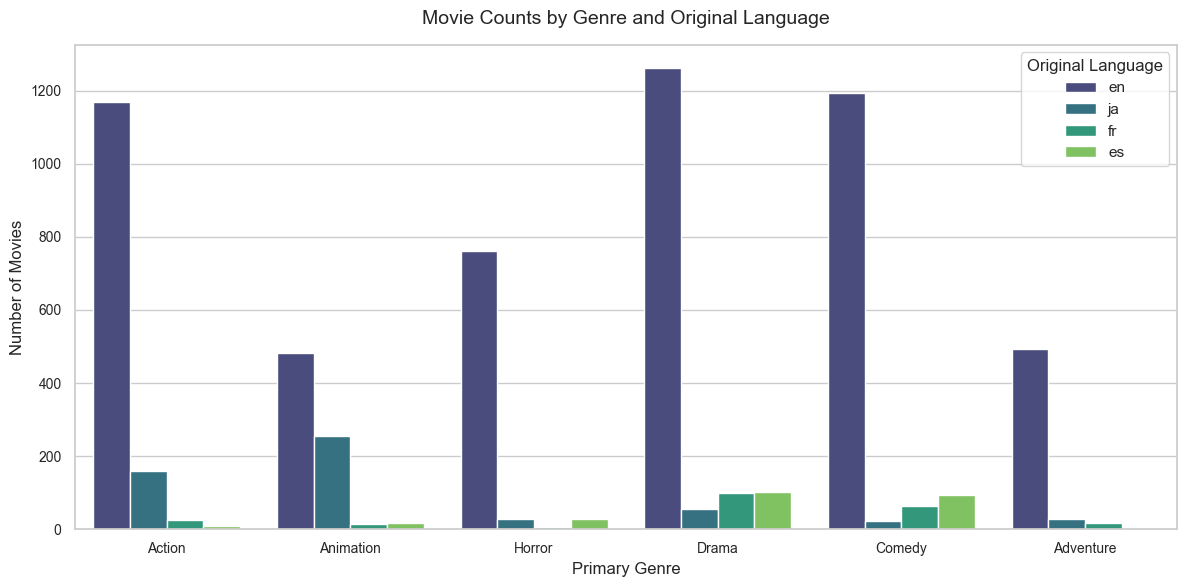

In [6]:
# Get top genres and languages
top_genres = df['Primary_Genre'].value_counts().nlargest(6).index
top_languages = df['Original_Language'].value_counts().nlargest(4).index

df_filtered_both = df[df['Primary_Genre'].isin(top_genres) & df['Original_Language'].isin(top_languages)]

# Grouped count plot
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_filtered_both, 
    x='Primary_Genre', 
    hue='Original_Language', 
    palette='viridis'
)

plt.title('Movie Counts by Genre and Original Language', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Number of Movies')
plt.legend(title='Original Language', loc='upper right')
plt.tight_layout()
plt.show()
